In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score

In [2]:
df = pd.read_csv('covid_19_data.csv')

In [3]:
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [5]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  str    
 2   Province/State   228326 non-null  str    
 3   Country/Region   306429 non-null  str    
 4   Last Update      306429 non-null  str    
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 18.7 MB


In [7]:
# There are missing value columns

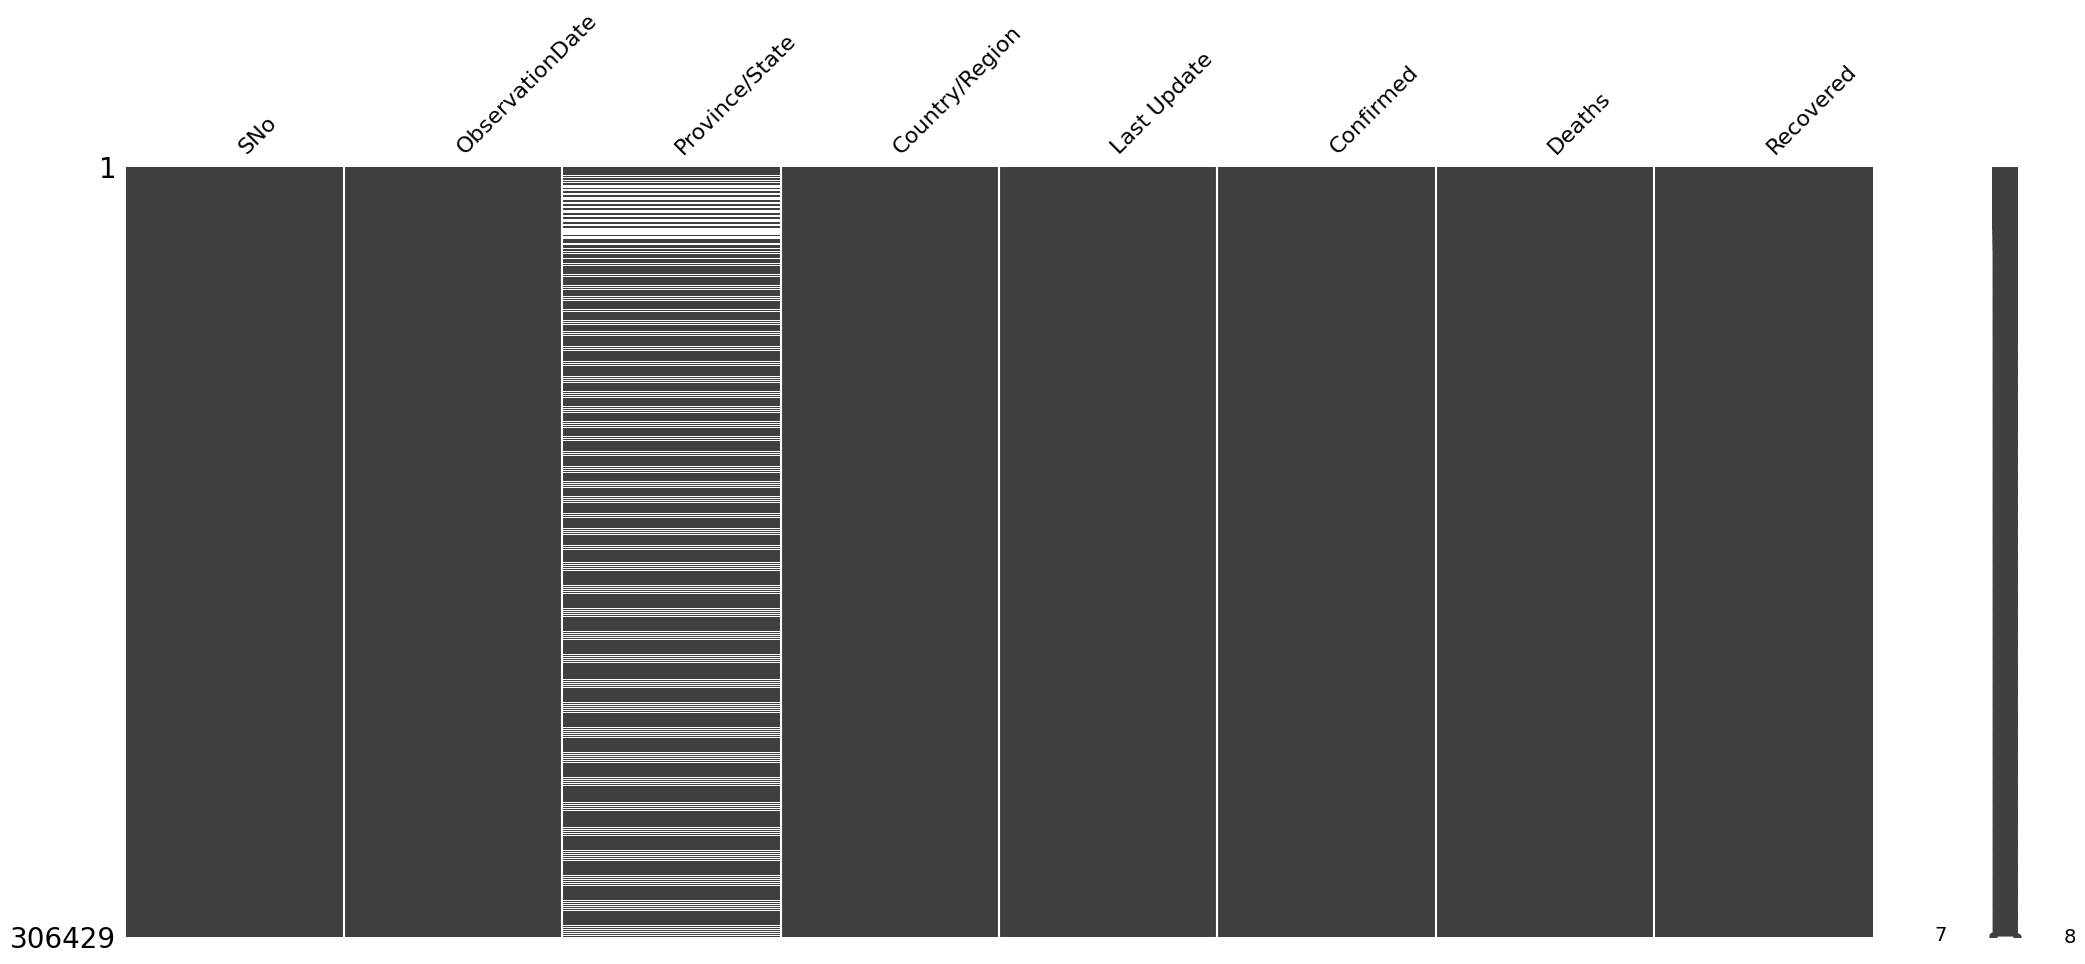

In [8]:
import missingno as msno
msno.matrix(df=df)
plt.show()

In [9]:
df = df.drop('SNo',axis=1)

In [10]:
df.sample()

,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
297388,05/18/2021,NaN,Singapore,2021-05-19 04:20:42,61651.0,31.0,61134.0


In [11]:
df['ObservationDate']  =  pd.to_datetime(df['ObservationDate'],errors='raise')
# There is no error as errors were not raised

In [12]:
df['ObservationDate'].info()
# This is a valauable piece of information as we are dealing with time series data

<class 'pandas.Series'>
RangeIndex: 306429 entries, 0 to 306428
Series name: ObservationDate
Non-Null Count   Dtype         
--------------   -----         
306429 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 2.3 MB


In [13]:
df.nunique()

ObservationDate       494
Province/State        736
Country/Region        229
Last Update          1905
Confirmed          107146
Deaths              20089
Recovered           74541
dtype: int64

In [14]:
df['Confirmed'] = pd.to_numeric(df['Confirmed'],errors='raise',downcast='integer')

In [15]:
df['Deaths'] = pd.to_numeric(df['Deaths'],errors='raise',downcast='integer')

In [16]:
df['Recovered'] = pd.to_numeric(df['Recovered'],errors='raise',downcast='integer')

In [17]:
df.head()

,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1,0,0
1,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14,0,0
2,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6,0,0
3,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1,0,0
4,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0,0,0


In [18]:
df.corr(numeric_only=True)

,Confirmed,Deaths,Recovered
Confirmed,1.000000,0.888416,0.633479
Deaths,0.888416,1.000000,0.538416
Recovered,0.633479,0.538416,1.000000


In [19]:
df.describe()

,ObservationDate,Confirmed,Deaths,Recovered
count,306429,3.064290e+05,306429.000000,3.064290e+05
mean,2020-11-06 01:54:54.146442,8.567091e+04,2036.403268,5.042029e+04
min,2020-01-22 00:00:00,-3.028440e+05,-178.000000,-8.544050e+05
25%,2020-07-30 00:00:00,1.042000e+03,13.000000,1.100000e+01
50%,2020-11-10 00:00:00,1.037500e+04,192.000000,1.751000e+03
75%,2021-02-18 00:00:00,5.075200e+04,1322.000000,2.027000e+04
max,2021-05-29 00:00:00,5.863138e+06,112385.000000,6.399531e+06
std,NaN,2.775516e+05,6410.938048,2.015124e+05


In [20]:
# From the given data is confirmed that there are many outliers present here

In [61]:
df['Last Update'].str.split(r'[0-9]{4}:[0-9]{2}:[0-9]{2}',regex=True)
# If we run this command we find that there are columns which have different date and time format acorrdingly.
# Also found out that there are merged variables and other inconsistenies found , we need a way to fix this

0             [1/22/2020 17:00]
1             [1/22/2020 17:00]
2             [1/22/2020 17:00]
3             [1/22/2020 17:00]
4             [1/22/2020 17:00]
                  ...          
306424    [2021-05-30 04:20:55]
306425    [2021-05-30 04:20:55]
306426    [2021-05-30 04:20:55]
306427    [2021-05-30 04:20:55]
306428    [2021-05-30 04:20:55]
Name: Last Update, Length: 306429, dtype: object